In [8]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

In [9]:
from sklearn.ensemble import GradientBoostingRegressor
import xgboost
from sklearn.metrics        import mean_absolute_error, mean_squared_error, r2_score

In [10]:
print("Loading data...")
df = pd.read_csv('D:\\Users\\Md Mahfuzur Rahman\\Desktop\\Research\\for_me\\cleaned_combined_data.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)


Loading data...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42611 entries, 0 to 42610
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   datetime       42611 non-null  datetime64[ns]
 1   demand_mw      42611 non-null  int64         
 2   load_shedding  42611 non-null  int64         
 3   temp_mean      42611 non-null  float64       
 4   wspd_mean      42611 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 1.6 MB


In [12]:
df.head(5)

,datetime,demand_mw,load_shedding,temp_mean,wspd_mean
0,2020-01-01 03:00:00,5351,0,18.65,1.80
1,2020-01-01 06:00:00,5346,0,23.73,3.00
2,2020-01-01 09:00:00,6654,0,25.25,4.58
3,2020-01-01 12:00:00,6750,0,21.05,2.17
4,2020-01-01 15:00:00,6546,0,18.82,0.30


In [13]:

df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['dayofyear'] = df['datetime'].dt.dayofyear

# -----------------------------
# Cyclic time features
# -----------------------------

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['doy_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)


# -----------------------------
# Lag features
# -----------------------------

for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]:
    df[f'lag{lag}'] = df['demand_mw'].shift(lag)


# -----------------------------
# Rolling features
# IMPORTANT: shift(1)
# prevents target leakage
# -----------------------------

past_demand = df['demand_mw'].shift(1)

for window in [6, 12, 24, 48, 168]:

    df[f'roll{window}_mean'] = (
        past_demand.rolling(window).mean()
    )

    df[f'roll{window}_std'] = (
        past_demand.rolling(window).std()
    )


# Remove NaN
df = df.dropna().reset_index(drop=True)

In [14]:
df.head()

,datetime,demand_mw,load_shedding,temp_mean,wspd_mean,hour,dayofweek,month,dayofyear,hour_sin,...,roll6_mean,roll6_std,roll12_mean,roll12_std,roll24_mean,roll24_std,roll48_mean,roll48_std,roll168_mean,roll168_std
0,2020-04-04 03:00:00,6806,0,28.30,3.37,3,5,4,95,7.071068e-01,...,7483.000000,957.484830,7642.916667,920.056961,7766.791667,922.854785,7734.937500,895.179012,8011.303571,974.716374
1,2020-04-04 06:00:00,6392,0,33.02,5.47,6,5,4,95,1.000000e+00,...,7511.166667,929.703053,7573.750000,951.292243,7721.791667,942.902825,7730.770833,899.100951,8004.434524,979.136315
2,2020-04-04 09:00:00,7014,0,34.03,10.17,9,5,4,95,7.071068e-01,...,7411.666667,1023.934894,7412.500000,975.688801,7644.375000,973.429920,7720.562500,911.637197,7996.244048,986.850664
3,2020-04-04 12:00:00,7905,0,31.37,4.27,12,5,4,95,1.224647e-16,...,7277.000000,1012.241868,7261.250000,871.230387,7634.125000,978.932885,7709.104167,917.087068,7992.035714,989.535262
4,2020-04-04 15:00:00,8138,0,26.90,1.80,15,5,4,95,-7.071068e-01,...,7204.166667,932.898583,7376.833333,855.524595,7571.208333,905.249760,7707.875000,916.777651,7984.083333,984.794896


In [15]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,42275,2023-05-19 10:59:51.569485568,2020-04-04 03:00:00,2022-01-18 09:30:00,2023-05-23 06:00:00,2024-09-21 03:30:00,2025-12-31 23:00:00,NaN
demand_mw,42275.0,10582.225855,3622.0,8818.0,10537.0,12370.0,17150.0,2361.670597
load_shedding,42275.0,119.877209,0.0,0.0,0.0,74.0,1500.0,275.812976
temp_mean,42275.0,26.187352,11.05,23.38,27.2,29.57,38.38,4.86722
wspd_mean,42275.0,4.797287,0.0,2.97,4.27,6.2,28.07,2.560986
hour,42275.0,12.028054,1.0,6.0,12.0,18.0,23.0,6.592995
dayofweek,42275.0,3.004802,0.0,1.0,3.0,5.0,6.0,2.000178
month,42275.0,6.583513,1.0,4.0,7.0,10.0,12.0,3.463384
dayofyear,42275.0,185.038557,1.0,94.0,187.0,277.0,366.0,105.903736
hour_sin,42275.0,0.000212,-1.0,-0.707107,0.0,0.707107,1.0,0.725247


In [16]:
df.shape

(42275, 37)

In [17]:
df.columns

Index(['datetime', 'demand_mw', 'load_shedding', 'temp_mean', 'wspd_mean',
       'hour', 'dayofweek', 'month', 'dayofyear', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
       'lag1', 'lag2', 'lag3', 'lag6', 'lag12', 'lag24', 'lag48', 'lag72',
       'lag168', 'lag336', 'roll6_mean', 'roll6_std', 'roll12_mean',
       'roll12_std', 'roll24_mean', 'roll24_std', 'roll48_mean', 'roll48_std',
       'roll168_mean', 'roll168_std'],
      dtype='object')

In [18]:
FEATURES = [
    'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos','doy_sin','doy_cos',

    'load_shedding','temp_mean','wspd_mean',

    'lag1','lag2','lag3','lag6','lag12','lag24','lag48','lag72','lag168','lag336',

    'roll6_mean','roll6_std','roll12_mean','roll12_std','roll24_mean','roll24_std',
    'roll48_mean','roll48_std','roll168_mean','roll168_std'
]

TARGET = 'demand_mw'

In [19]:
from sklearn.model_selection import train_test_split
X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Reset indices for easier access
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Create aliases for backward compatibility
X_tr, X_te = X_train, X_test
y_tr, y_te = y_train, y_test

print(f"Train rows: {len(X_train):,}   Test rows: {len(X_test):,}")


Train rows: 33,820   Test rows: 8,455


In [20]:
from sklearn.preprocessing import StandardScaler
import torch

X_scaler = StandardScaler()

X_tr_sc = X_scaler.fit_transform(X_tr)
X_te_sc = X_scaler.transform(X_te)

# PyTorch tensors
X_tr = torch.tensor(X_tr_sc, dtype=torch.float32)
X_te = torch.tensor(X_te_sc, dtype=torch.float32)

y_tr = torch.tensor(y_tr, dtype=torch.float32).reshape(-1, 1)
y_te = torch.tensor(y_te, dtype=torch.float32).reshape(-1, 1)

In [21]:
y_te

tensor([[7063.],
        [7010.],
        [7382.],
        ...,
        [9691.],
        [9286.],
        [8808.]])

In [22]:
def metrics(name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    acc  = max(0.0, 1.0 - mape / 100.0) * 100
    return dict(Model=name,
                Accuracy=round(acc, 3),
                MAE=round(mae, 1),
                RMSE=round(rmse, 1),
                MAPE=round(mape, 3),
                R2=round(r2, 4))

results = []  # Store results for all models

### ML MODEL

In [23]:
# ── B2. Gradient Boosting ─────────────────────────────────────────────────────
print("Running Gradient Boosting...")
m_gb = GradientBoostingRegressor(n_estimators=700,
                                learning_rate=0.05128257080305278,
                                max_depth=4,
                                min_samples_split=20,
                                min_samples_leaf=17,
                                subsample=0.6972258345651443,
                                max_features=None,
                                loss='huber',
                                random_state=42)
m_gb.fit(X_tr_sc, y_tr)
pred_gb = m_gb.predict(X_te_sc)
results.append(metrics('Gradient Boosting', y_te, pred_gb))

Running Gradient Boosting...


In [24]:

print("Running XGBoost...")
m_xgb_2 = xgboost.XGBRegressor(n_estimators=800,
                             learning_rate=0.026340059352236846,
                             max_depth=5,
                             min_child_weight=11,
                             subsample=0.7263709147024497,
                             colsample_bytree=0.9493553396095371,
                             gamma=0.03818554358601167,
                             reg_alpha=4.0561758823329404e-08,
                             reg_lambda=2.310596649947486, random_state=42)
m_xgb_2.fit(X_tr_sc, y_tr)
pred_xgb = m_xgb_2.predict(X_te_sc)
results.append(metrics('XGBoost', y_te, pred_xgb))

Running XGBoost...


### Deep Learning Model

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim


train_loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=256,
    shuffle=False
)


class ResidualANN(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.input_layer = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.GELU()
        )

        self.block1 = nn.Sequential(
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256)
        )

        self.block2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 128)
        )

        self.block3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 64)
        )

        self.output = nn.Sequential(
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

        self.proj1 = nn.Linear(256, 128)


    def forward(self, x):

        x = self.input_layer(x)

        # Residual block 1
        residual = x
        x = self.block1(x)
        x = x + residual
        x = nn.functional.gelu(x)

        # Residual block 2
        residual = self.proj1(x)
        x = self.block2(x)
        x = x + residual
        x = nn.functional.gelu(x)

        # Residual block 3
        residual = x[:, :64]
        x = self.block3(x)
        x = x + residual
        x = nn.functional.gelu(x)

        return self.output(x)


model = ResidualANN(X_tr.shape[1])

criterion = nn.MSELoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=15
)


epochs = 300

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        prediction = model(X_batch)

        loss = criterion(prediction, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    scheduler.step(avg_loss)

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"Loss: {avg_loss:.6f} "
            f"LR: {optimizer.param_groups[0]['lr']:.7f}"
        )

Epoch 10/300 Loss: 1863405.113252 LR: 0.0010000
Epoch 20/300 Loss: 1745448.719984 LR: 0.0010000
Epoch 30/300 Loss: 491346.693080 LR: 0.0010000
Epoch 40/300 Loss: 523562.362371 LR: 0.0010000
Epoch 50/300 Loss: 2580196.008694 LR: 0.0010000
Epoch 60/300 Loss: 1198972.017505 LR: 0.0005000
Epoch 70/300 Loss: 242530.957384 LR: 0.0005000
Epoch 80/300 Loss: 575750.374794 LR: 0.0005000
Epoch 90/300 Loss: 269916.436707 LR: 0.0005000
Epoch 100/300 Loss: 130391.245741 LR: 0.0002500
Epoch 110/300 Loss: 235317.740616 LR: 0.0002500
Epoch 120/300 Loss: 274618.754875 LR: 0.0002500
Epoch 130/300 Loss: 119301.465769 LR: 0.0002500
Epoch 140/300 Loss: 307800.912183 LR: 0.0002500
Epoch 150/300 Loss: 395312.522336 LR: 0.0002500
Epoch 160/300 Loss: 85657.830504 LR: 0.0002500
Epoch 170/300 Loss: 111580.316509 LR: 0.0001250
Epoch 180/300 Loss: 122037.694182 LR: 0.0001250
Epoch 190/300 Loss: 72421.933770 LR: 0.0001250
Epoch 200/300 Loss: 56345.797382 LR: 0.0001250
Epoch 210/300 Loss: 73943.038174 LR: 0.0001250
E

In [26]:
model.eval()

with torch.no_grad():
    y_pred = model(X_te)

y_pred_ann = y_pred.numpy()
y_test = y_te.numpy()
results.append(metrics('ANN', y_test, y_pred_ann))

### Time Serices Model SARIMA

In [27]:
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast

In [28]:
df = pd.read_csv("D:\\Users\\Md Mahfuzur Rahman\\Desktop\\Research\\for_me\\cleaned_combined_data.csv", parse_dates=["datetime"])
df["unique_id"] = "BD"
df.head()

,datetime,demand_mw,load_shedding,temp_mean,wspd_mean,unique_id
0,2020-01-01 03:00:00,5351,0,18.65,1.80,BD
1,2020-01-01 06:00:00,5346,0,23.73,3.00,BD
2,2020-01-01 09:00:00,6654,0,25.25,4.58,BD
3,2020-01-01 12:00:00,6750,0,21.05,2.17,BD
4,2020-01-01 15:00:00,6546,0,18.82,0.30,BD


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42611 entries, 0 to 42610
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   datetime       42611 non-null  datetime64[ns]
 1   demand_mw      42611 non-null  int64         
 2   load_shedding  42611 non-null  int64         
 3   temp_mean      42611 non-null  float64       
 4   wspd_mean      42611 non-null  float64       
 5   unique_id      42611 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 2.0+ MB


In [30]:
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['dayofyear'] = df['datetime'].dt.dayofyear

# -----------------------------
# Cyclic time features
# -----------------------------

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['doy_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)


# -----------------------------
# Lag features
# -----------------------------

for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]:
    df[f'lag{lag}'] = df['demand_mw'].shift(lag)


# -----------------------------
# Rolling features
# IMPORTANT: shift(1)
# prevents target leakage
# -----------------------------

past_demand = df['demand_mw'].shift(1)

for window in [6, 12, 24, 48, 168]:

    df[f'roll{window}_mean'] = (
        past_demand.rolling(window).mean()
    )

    df[f'roll{window}_std'] = (
        past_demand.rolling(window).std()
    )


# Remove NaN
df = df.dropna().reset_index(drop=True)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42275 entries, 0 to 42274
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   datetime       42275 non-null  datetime64[ns]
 1   demand_mw      42275 non-null  int64         
 2   load_shedding  42275 non-null  int64         
 3   temp_mean      42275 non-null  float64       
 4   wspd_mean      42275 non-null  float64       
 5   unique_id      42275 non-null  object        
 6   hour           42275 non-null  int32         
 7   dayofweek      42275 non-null  int32         
 8   month          42275 non-null  int32         
 9   dayofyear      42275 non-null  int32         
 10  hour_sin       42275 non-null  float64       
 11  hour_cos       42275 non-null  float64       
 12  dow_sin        42275 non-null  float64       
 13  dow_cos        42275 non-null  float64       
 14  month_sin      42275 non-null  float64       
 15  month_cos      4227

In [32]:
df_ext = (
    df[["datetime", "demand_mw",

        'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos','doy_sin','doy_cos',
    
        'load_shedding','temp_mean','wspd_mean',
    
        'lag1','lag2','lag3','lag6','lag12','lag24','lag48','lag72','lag168','lag336',
    
        'roll6_mean','roll6_std','roll12_mean','roll12_std','roll24_mean','roll24_std',
        'roll48_mean','roll48_std','roll168_mean','roll168_std']]
    .rename(columns={"datetime": "ds", "demand_mw": "y"})
    .assign(unique_id=df["unique_id"])
)

In [33]:
# Sort chronologically
sorted_df = df_ext.sort_values("ds").reset_index(drop=True)

# Last 24 rows for testing
test_size = 24

test = sorted_df.iloc[-test_size:].copy()

# Remaining data
remaining_df = sorted_df.iloc[:-test_size].copy()

# Last 20% of the remaining data for training
train_size = int(len(remaining_df) * 0.20)

train = remaining_df.iloc[-train_size:].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train time range:",
      train["ds"].min(), "to", train["ds"].max())

print("Test time range:",
      test["ds"].min(), "to", test["ds"].max())

print("\nTrain tail:")
print(train.tail())

print("\nTest:")
print(test)

Train shape: (8450, 34)
Test shape: (24, 34)
Train time range: 2024-12-23 08:00:00 to 2025-12-30 22:00:00
Test time range: 2025-12-30 23:00:00 to 2025-12-31 23:00:00

Train tail:
                       ds      y  hour_sin      hour_cos   dow_sin  dow_cos  \
42246 2025-12-30 18:00:00  10871 -1.000000 -1.836970e-16  0.781831  0.62349   
42247 2025-12-30 19:00:00  10931 -0.965926  2.588190e-01  0.781831  0.62349   
42248 2025-12-30 20:00:00  10754 -0.866025  5.000000e-01  0.781831  0.62349   
42249 2025-12-30 21:00:00  10484 -0.707107  7.071068e-01  0.781831  0.62349   
42250 2025-12-30 22:00:00  10049 -0.500000  8.660254e-01  0.781831  0.62349   

          month_sin  month_cos   doy_sin   doy_cos  ...   roll6_std  \
42246 -2.449294e-16        1.0 -0.017213  0.999852  ...  511.522434   
42247 -2.449294e-16        1.0 -0.017213  0.999852  ...  571.207639   
42248 -2.449294e-16        1.0 -0.017213  0.999852  ...  573.068728   
42249 -2.449294e-16        1.0 -0.017213  0.999852  ...  605.0

In [34]:
# Make the future exogenous dataframe from the prepared SARIMA frame.
# StatsForecast expects ds, unique_id, and regressors, but not the target y.
futr_exog_df = df_ext.drop(columns=["y"]).copy()

# Make sure datetime type is identical
train["ds"] = pd.to_datetime(train["ds"])
test["ds"] = pd.to_datetime(test["ds"])
futr_exog_df["ds"] = pd.to_datetime(futr_exog_df["ds"])

# Future exogenous variables corresponding EXACTLY to test period
futr_exog_24 = (
    futr_exog_df[
        futr_exog_df["ds"].isin(test["ds"])
    ]
    .sort_values("ds")
    .copy()
)

print("Test:", test.shape)
print("Future exog:", futr_exog_24.shape)

print("\nTest dates:")
print(test["ds"].head())
print(test["ds"].tail())

print("\nFuture exog dates:")
print(futr_exog_24["ds"].head())
print(futr_exog_24["ds"].tail())

Test: (24, 34)
Future exog: (24, 33)

Test dates:
42251   2025-12-30 23:00:00
42252   2025-12-31 01:00:00
42253   2025-12-31 02:00:00
42254   2025-12-31 03:00:00
42255   2025-12-31 04:00:00
Name: ds, dtype: datetime64[ns]
42270   2025-12-31 19:00:00
42271   2025-12-31 20:00:00
42272   2025-12-31 21:00:00
42273   2025-12-31 22:00:00
42274   2025-12-31 23:00:00
Name: ds, dtype: datetime64[ns]

Future exog dates:
42251   2025-12-30 23:00:00
42252   2025-12-31 01:00:00
42253   2025-12-31 02:00:00
42254   2025-12-31 03:00:00
42255   2025-12-31 04:00:00
Name: ds, dtype: datetime64[ns]
42270   2025-12-31 19:00:00
42271   2025-12-31 20:00:00
42272   2025-12-31 21:00:00
42273   2025-12-31 22:00:00
42274   2025-12-31 23:00:00
Name: ds, dtype: datetime64[ns]


In [35]:
models = [
    AutoARIMA(
        season_length=24, max_p=2, max_q=2, max_P=1, max_Q=1, max_order=4, approximation=True,alias="SARIMA_exog"
    )
]

sf = StatsForecast(models=models, freq="H")
sf.fit(df=train)

StatsForecast(models=[SARIMA_exog])

In [36]:
Sarima_exog_preds = sf.predict(h=24, X_df=futr_exog_24,level=[80])

In [37]:
test_df = test.merge(Sarima_exog_preds, on=["unique_id", "ds"], how="left")
test_df

,ds,y,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,...,roll24_mean,roll24_std,roll48_mean,roll48_std,roll168_mean,roll168_std,unique_id,SARIMA_exog,SARIMA_exog-lo-80,SARIMA_exog-hi-80
0,2025-12-30 23:00:00,9503,-2.588190e-01,9.659258e-01,0.781831,0.623490,-2.449294e-16,1.0,-1.721336e-02,0.999852,...,9376.833333,1270.105941,9410.645833,1235.777100,9135.750000,1250.299383,BD,9359.103876,8870.790333,9847.417419
1,2025-12-31 01:00:00,8162,2.588190e-01,9.659258e-01,0.974928,-0.222521,-2.449294e-16,1.0,6.432491e-16,1.000000,...,9361.750000,1266.200075,9391.375000,1226.754161,9136.154762,1250.407842,BD,7099.931643,6563.620592,7636.242694
2,2025-12-31 02:00:00,7618,5.000000e-01,8.660254e-01,0.974928,-0.222521,-2.449294e-16,1.0,6.432491e-16,1.000000,...,9308.458333,1289.421845,9353.520833,1236.233039,9126.160714,1251.449920,BD,7251.156448,6714.845397,7787.467500
3,2025-12-31 03:00:00,7349,7.071068e-01,7.071068e-01,0.974928,-0.222521,-2.449294e-16,1.0,6.432491e-16,1.000000,...,9288.250000,1312.725649,9316.604167,1261.323819,9105.958333,1248.214976,BD,7198.551197,6662.240146,7734.862248
4,2025-12-31 04:00:00,7122,8.660254e-01,5.000000e-01,0.974928,-0.222521,-2.449294e-16,1.0,6.432491e-16,1.000000,...,9273.666667,1332.937086,9300.729167,1281.454987,9084.625000,1247.428846,BD,7111.446731,6575.135680,7647.757782
5,2025-12-31 05:00:00,7088,9.659258e-01,2.588190e-01,0.974928,-0.222521,-2.449294e-16,1.0,6.432491e-16,1.000000,...,9263.041667,1349.624826,9285.958333,1302.667051,9062.982143,1249.762054,BD,7385.170681,6848.859630,7921.481732
6,2025-12-31 06:00:00,7293,1.000000e+00,6.123234e-17,0.974928,-0.222521,-2.449294e-16,1.0,6.432491e-16,1.000000,...,9255.666667,1361.449600,9277.166667,1316.261070,9042.208333,1253.428691,BD,7730.246803,7193.935752,8266.557854
7,2025-12-31 07:00:00,7516,9.659258e-01,-2.588190e-01,0.974928,-0.222521,-2.449294e-16,1.0,6.432491e-16,1.000000,...,9259.958333,1354.801044,9277.354167,1315.971714,9024.791667,1257.301720,BD,7909.968246,7373.657195,8446.279297
8,2025-12-31 08:00:00,8222,8.660254e-01,-5.000000e-01,0.974928,-0.222521,-2.449294e-16,1.0,6.432491e-16,1.000000,...,9258.500000,1356.738032,9282.708333,1308.084290,9013.113095,1262.169534,BD,8747.219906,8210.908855,9283.530957
9,2025-12-31 09:00:00,8707,7.071068e-01,-7.071068e-01,0.974928,-0.222521,-2.449294e-16,1.0,6.432491e-16,1.000000,...,9264.416667,1351.675383,9293.875000,1296.399361,9011.386905,1263.056975,BD,8867.638109,8331.327058,9403.949160


In [38]:
test_df.isna().sum()

ds                   0
y                    0
hour_sin             0
hour_cos             0
dow_sin              0
dow_cos              0
month_sin            0
month_cos            0
doy_sin              0
doy_cos              0
load_shedding        0
temp_mean            0
wspd_mean            0
lag1                 0
lag2                 0
lag3                 0
lag6                 0
lag12                0
lag24                0
lag48                0
lag72                0
lag168               0
lag336               0
roll6_mean           0
roll6_std            0
roll12_mean          0
roll12_std           0
roll24_mean          0
roll24_std           0
roll48_mean          0
roll48_std           0
roll168_mean         0
roll168_std          0
unique_id            0
SARIMA_exog          1
SARIMA_exog-lo-80    1
SARIMA_exog-hi-80    1
dtype: int64

In [39]:
y_test = test_df['y']
y_pred_sarima = test_df['SARIMA_exog']

In [40]:
valid = test_df[["y", "SARIMA_exog"]].notna().all(axis=1)

if valid.sum() == 0:
    raise ValueError(
        "SARIMA evaluation is empty: no matching forecast rows remained after aligning the test dates and filtering NaN predictions."
    )

y_test = test_df.loc[valid, "y"].to_numpy()
y_pred_sarima = test_df.loc[valid, "SARIMA_exog"].to_numpy()


In [41]:
y_test

array([ 9503,  8162,  7618,  7349,  7122,  7088,  7293,  7516,  8222,
        8707,  8598,  8691,  9267, 10078,  9588,  8499,  8053,  8551,
        9770,  9865,  9740,  9691,  9286])

In [42]:
results.append(metrics('Sarima', y_test, y_pred_sarima))

In [43]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

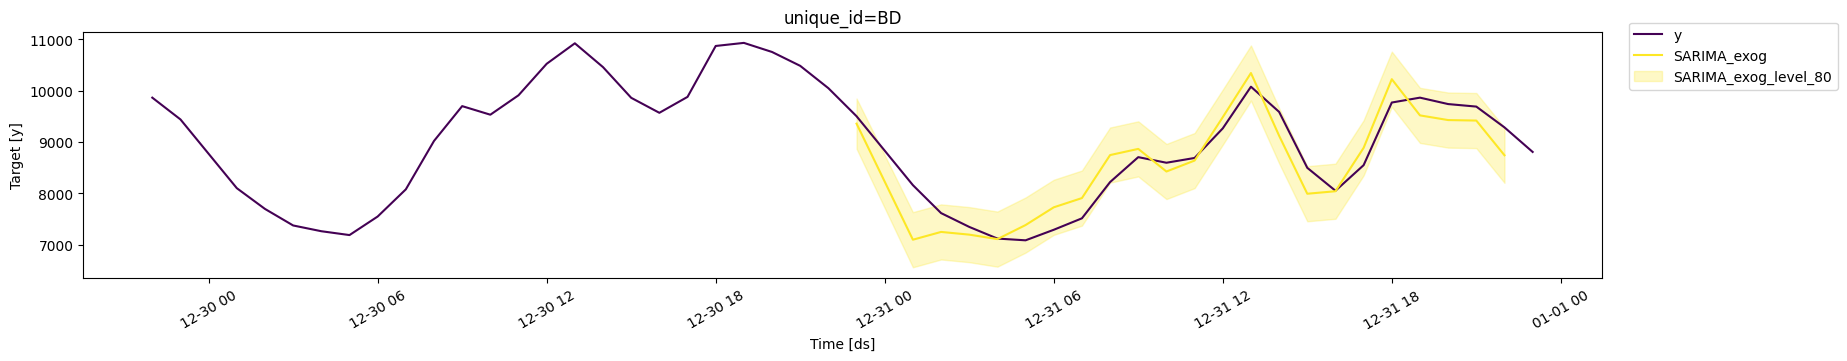

In [44]:
plot_series(
    df=train,
    forecasts_df=test_df,
    id_col="unique_id",
    max_insample_length=24,
    models=["SARIMA_exog"],
    level=[80],
    palette="viridis"
)

In [45]:
import os
OUTPUT_DIR = '.'  # Save results to current directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [46]:
# ── 4. RESULTS TABLE ─────────────────────────────────────────────────────────
df_res = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
df_res.insert(0, 'Rank', range(1, len(df_res) + 1))
df_res['CI_Coverage_90pct'] = df_res.get('CI_Coverage_90pct', np.nan)

print("\n" + "="*80)
print("  ELECTRICITY DEMAND FORECASTING — ALL MODEL RESULTS")
print("="*80)
print(df_res[['Rank','Model','Accuracy','MAE','RMSE','MAPE','R2',
              'CI_Coverage_90pct']].to_string(index=False))
print("="*80)

df_res.to_csv(f'{OUTPUT_DIR}/model_results_top.csv', index=False)
print(f"\nResults saved → {OUTPUT_DIR}/model_results_top.csv")



  ELECTRICITY DEMAND FORECASTING — ALL MODEL RESULTS
 Rank             Model  Accuracy   MAE  RMSE  MAPE     R2  CI_Coverage_90pct
    1 Gradient Boosting    98.255 203.3 271.9 1.745 0.9850                NaN
    2           XGBoost    98.134 219.7 287.5 1.866 0.9832                NaN
    3               ANN    98.120 224.8 309.9 1.880 0.9805                NaN
    4            Sarima    96.191 325.9 393.8 3.809 0.8293                NaN

Results saved → ./model_results_top.csv


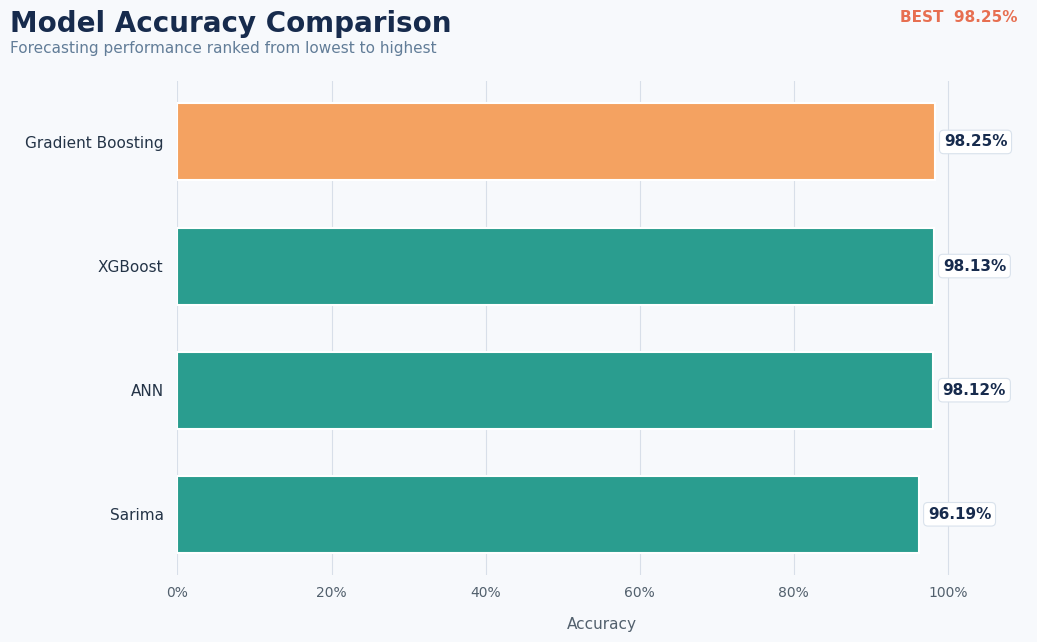

Plot saved to: .\model_accuracy_bar_plot.png


In [47]:
# Presentation-ready model accuracy ranking
import textwrap
from matplotlib import pyplot as plt

plot_df = df_res.sort_values("Accuracy", ascending=True).copy()
plot_df["Label"] = plot_df["Model"].map(
    lambda name: "\n".join(textwrap.wrap(str(name), width=22))
)

fig, ax = plt.subplots(figsize=(12, 7), facecolor="#F7F9FC")
ax.set_facecolor("#F7F9FC")

# Highlight the best model while keeping the remaining bars visually balanced.
bar_colors = [
    "#F4A261" if rank == plot_df["Rank"].min() else "#2A9D8F"
    for rank in plot_df["Rank"]
]

bars = ax.barh(
    plot_df["Label"],
    plot_df["Accuracy"],
    color=bar_colors,
    height=0.62,
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)

max_accuracy = float(plot_df["Accuracy"].max())
ax.set_xlim(0, max(100, max_accuracy + 12))
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
ax.grid(axis="x", color="#CBD5E1", linewidth=0.8, alpha=0.7, zorder=0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=11, colors="#243447", pad=10)
ax.tick_params(axis="x", length=0, labelsize=10, colors="#52606D", pad=8)
ax.set_xlabel("Accuracy", fontsize=11, color="#52606D", labelpad=12)
ax.set_ylabel("")

for bar, accuracy in zip(bars, plot_df["Accuracy"]):
    ax.text(
        bar.get_width() + 1.2,
        bar.get_y() + bar.get_height() / 2,
        f"{accuracy:.2f}%",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#172B4D",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="#D9E2EC",
            linewidth=0.8,
        ),
        clip_on=False,
    )

fig.text(
    0.08, 0.96,
    "Model Accuracy Comparison",
    ha="left", va="top",
    fontsize=20, fontweight="bold", color="#172B4D",
)
fig.text(
    0.08, 0.915,
    "Forecasting performance ranked from lowest to highest",
    ha="left", va="top",
    fontsize=11, color="#627D98",
)
fig.text(
    0.92, 0.96,
    f"BEST  {max_accuracy:.2f}%",
    ha="right", va="top",
    fontsize=11, fontweight="bold", color="#E76F51",
)

plt.tight_layout(rect=[0.08, 0.05, 0.94, 0.88])

output_path = os.path.join(OUTPUT_DIR, "model_accuracy_bar_plot.png")
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Plot saved to: {output_path}")

In [48]:
# ============================================================
# RESEARCH PAPER VISUALIZATION SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

# Publication-friendly settings
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Create output directory
import os
os.makedirs("paper_figures", exist_ok=True)

# Make a working dataframe
plot_df = df.copy()

plot_df["datetime"] = pd.to_datetime(plot_df["datetime"])
plot_df = plot_df.sort_values("datetime").reset_index(drop=True)

print(plot_df.shape)
print(plot_df["datetime"].min())
print(plot_df["datetime"].max())

(42275, 38)
2020-04-04 03:00:00
2025-12-31 23:00:00


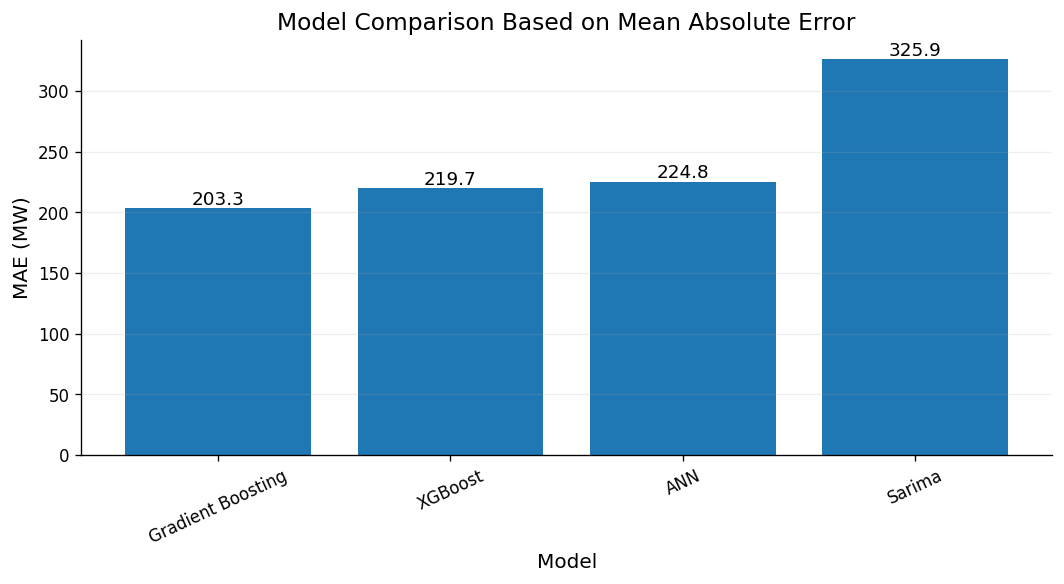

In [49]:
# ============================================================
# FIGURE 7A — MAE COMPARISON
# ============================================================

results_df = pd.DataFrame(results).copy()

# Remove duplicate model names if necessary
results_df = (
    results_df
    .drop_duplicates(subset="Model")
    .sort_values("MAE")
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    results_df["Model"],
    results_df["MAE"]
)

ax.set_title("Model Comparison Based on Mean Absolute Error")
ax.set_xlabel("Model")
ax.set_ylabel("MAE (MW)")

ax.tick_params(axis="x", rotation=25)

for bar, value in zip(bars, results_df["MAE"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "paper_figures/Fig7A_MAE_comparison.png",
    bbox_inches="tight"
)

plt.show()

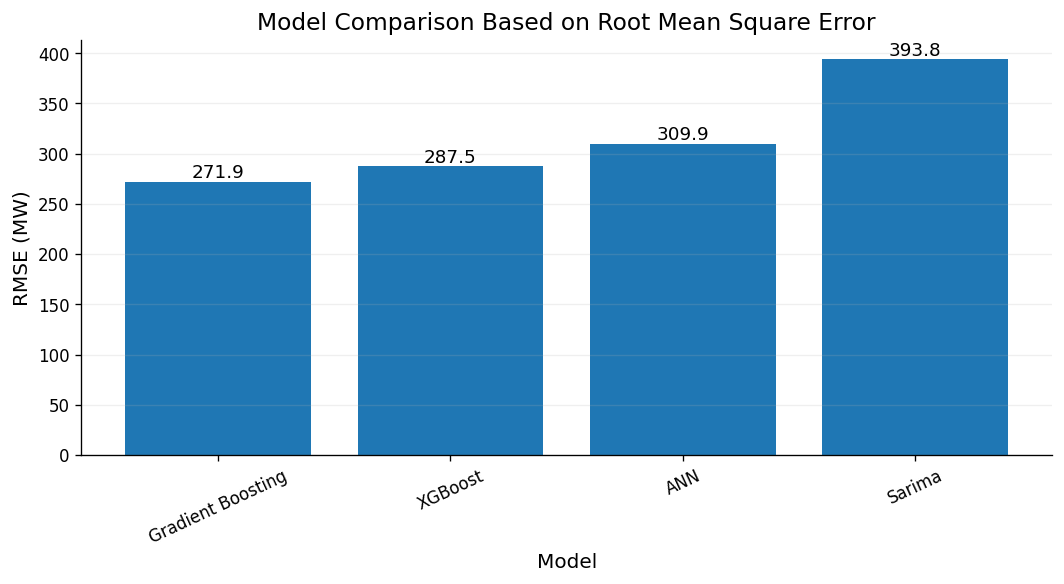

In [50]:
# ============================================================
# FIGURE 7B — RMSE COMPARISON
# ============================================================

results_df = (
    results_df
    .sort_values("RMSE")
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    results_df["Model"],
    results_df["RMSE"]
)

ax.set_title("Model Comparison Based on Root Mean Square Error")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE (MW)")

ax.tick_params(axis="x", rotation=25)

for bar, value in zip(bars, results_df["RMSE"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "paper_figures/Fig7B_RMSE_comparison.png",
    bbox_inches="tight"
)

plt.show()

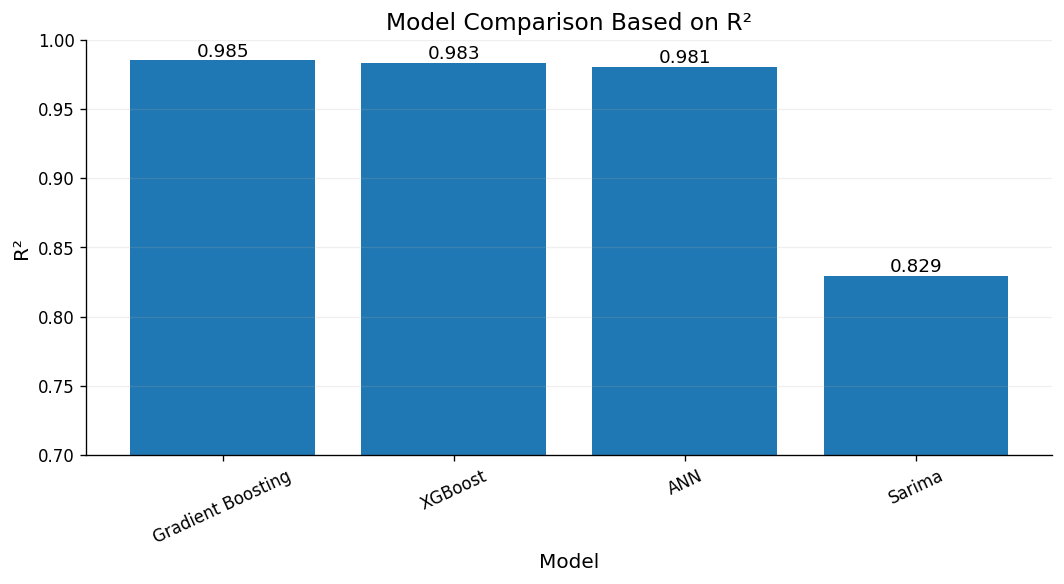

In [51]:
# ============================================================
# FIGURE 7C — R² COMPARISON
# ============================================================

results_df = (
    results_df
    .sort_values("R2", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    results_df["Model"],
    results_df["R2"]
)

ax.set_title("Model Comparison Based on R²")
ax.set_xlabel("Model")
ax.set_ylabel("R²")

ax.set_ylim(
    min(0.7, results_df["R2"].min() - 0.05),
    1.0
)

ax.tick_params(axis="x", rotation=25)

for bar, value in zip(bars, results_df["R2"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "paper_figures/Fig7C_R2_comparison.png",
    bbox_inches="tight"
)

plt.show()

Actual: 24
Gradient Boosting: 24
XGBoost: 24
ANN: 24
SARIMA: 24
Time: 24

Prediction dataframe:
              datetime   Actual  Gradient Boosting      XGBoost           ANN  \
0  2025-12-30 23:00:00   9503.0        9590.264148  9511.604492   9300.655273   
1  2025-12-31 01:00:00   8162.0        8531.822398  8554.907227   8338.839844   
2  2025-12-31 02:00:00   7618.0        7658.662304  7662.875488   7831.503418   
3  2025-12-31 03:00:00   7349.0        7347.705308  7273.351562   7460.604004   
4  2025-12-31 04:00:00   7122.0        7147.418651  7032.139160   7218.729492   
5  2025-12-31 05:00:00   7088.0        7003.917376  7074.936035   7124.691406   
6  2025-12-31 06:00:00   7293.0        7245.535522  7114.511230   7397.274414   
7  2025-12-31 07:00:00   7516.0        7856.581980  7746.911621   8007.190918   
8  2025-12-31 08:00:00   8222.0        8056.043054  7993.038086   8456.187500   
9  2025-12-31 09:00:00   8707.0        8545.489568  8587.950195   9142.056641   
10 2025-12-31

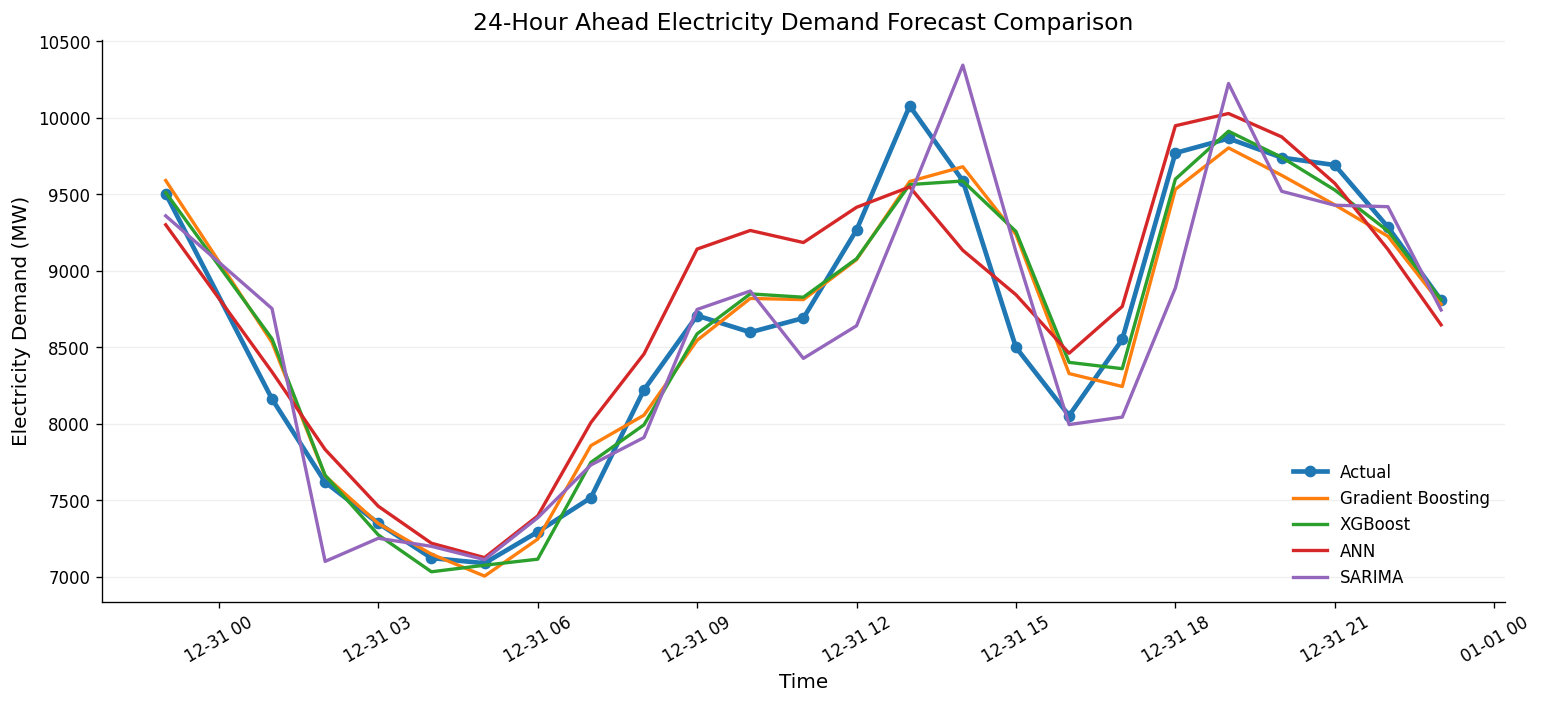

In [52]:
# ============================================================
# FIGURE 8 — ACTUAL VS MODEL PREDICTIONS
# Fair comparison over the SAME 24-hour horizon
# ============================================================

# ------------------------------------------------------------
# 1. Select the final 24 actual observations
# ------------------------------------------------------------
actual_24 = np.asarray(y_te).ravel()[-24:]

# ------------------------------------------------------------
# 2. Select the final 24 predictions from ML models
#    (because ML models predicted the whole test set)
# ------------------------------------------------------------
gb_24 = np.asarray(pred_gb).ravel()[-24:]
xgb_24 = np.asarray(pred_xgb).ravel()[-24:]
ann_24 = np.asarray(y_pred_ann).ravel()[-24:]

# ------------------------------------------------------------
# 3. Extract the 24 SARIMA forecasts
# ------------------------------------------------------------
sarima_24 = (
    Sarima_exog_preds["SARIMA_exog"]
    .to_numpy()
    .ravel()
)

# Safety check
print("Actual:", len(actual_24))
print("Gradient Boosting:", len(gb_24))
print("XGBoost:", len(xgb_24))
print("ANN:", len(ann_24))
print("SARIMA:", len(sarima_24))

# ------------------------------------------------------------
# 4. Select the corresponding final 24 timestamps
# ------------------------------------------------------------
test_times_24 = test["ds"].iloc[-24:].reset_index(drop=True)

print("Time:", len(test_times_24))

# ------------------------------------------------------------
# 5. Create comparison dataframe
# ------------------------------------------------------------
prediction_df = pd.DataFrame({
    "datetime": test_times_24,

    "Actual": actual_24,

    "Gradient Boosting": gb_24,

    "XGBoost": xgb_24,

    "ANN": ann_24,

    "SARIMA": sarima_24
})

print("\nPrediction dataframe:")
print(prediction_df)

# ------------------------------------------------------------
# 6. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    prediction_df["datetime"],
    prediction_df["Actual"],
    marker="o",
    linewidth=2.8,
    label="Actual"
)

ax.plot(
    prediction_df["datetime"],
    prediction_df["Gradient Boosting"],
    linewidth=2,
    label="Gradient Boosting"
)

ax.plot(
    prediction_df["datetime"],
    prediction_df["XGBoost"],
    linewidth=2,
    label="XGBoost"
)

ax.plot(
    prediction_df["datetime"],
    prediction_df["ANN"],
    linewidth=2,
    label="ANN"
)

ax.plot(
    prediction_df["datetime"],
    prediction_df["SARIMA"],
    linewidth=2,
    label="SARIMA"
)

# ------------------------------------------------------------
# 7. Figure formatting
# ------------------------------------------------------------
ax.set_title(
    "24-Hour Ahead Electricity Demand Forecast Comparison"
)

ax.set_xlabel("Time")
ax.set_ylabel("Electricity Demand (MW)")

ax.legend(
    loc="best",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.xticks(rotation=30)

plt.tight_layout()

# ------------------------------------------------------------
# 8. Save high-resolution figure for paper
# ------------------------------------------------------------
plt.savefig(
    "paper_figures/Fig8_actual_vs_predicted_24h.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [53]:
sf.predict(h=24, X_df=futr_exog_24, level=[80])

,unique_id,ds,SARIMA_exog,SARIMA_exog-lo-80,SARIMA_exog-hi-80
0,BD,2025-12-30 23:00:00,9359.103876,8870.790333,9847.417419
1,BD,2025-12-31 00:00:00,8752.775039,8219.144309,9286.405769
2,BD,2025-12-31 01:00:00,7099.931643,6563.620592,7636.242694
3,BD,2025-12-31 02:00:00,7251.156448,6714.845397,7787.467500
4,BD,2025-12-31 03:00:00,7198.551197,6662.240146,7734.862248
5,BD,2025-12-31 04:00:00,7111.446731,6575.135680,7647.757782
6,BD,2025-12-31 05:00:00,7385.170681,6848.859630,7921.481732
7,BD,2025-12-31 06:00:00,7730.246803,7193.935752,8266.557854
8,BD,2025-12-31 07:00:00,7909.968246,7373.657195,8446.279297
9,BD,2025-12-31 08:00:00,8747.219906,8210.908855,9283.530957


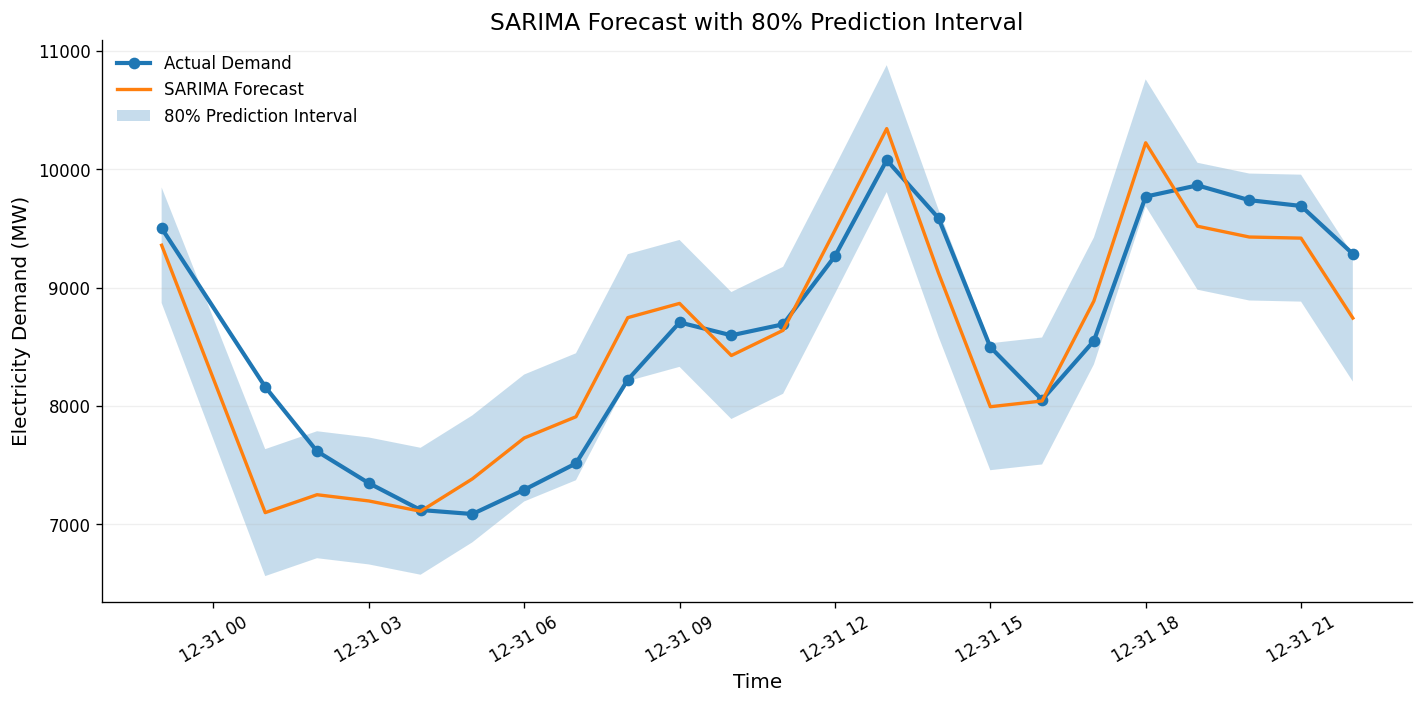

In [54]:
# ============================================================
# FIGURE 9 — SARIMA FORECAST WITH 80% PREDICTION INTERVAL
# ============================================================

sarima_plot = test_df.dropna(
    subset=[
        "SARIMA_exog",
        "SARIMA_exog-lo-80",
        "SARIMA_exog-hi-80"
    ]
).copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    sarima_plot["ds"],
    sarima_plot["y"],
    marker="o",
    linewidth=2.5,
    label="Actual Demand"
)

ax.plot(
    sarima_plot["ds"],
    sarima_plot["SARIMA_exog"],
    linewidth=2,
    label="SARIMA Forecast"
)

ax.fill_between(
    sarima_plot["ds"],
    sarima_plot["SARIMA_exog-lo-80"],
    sarima_plot["SARIMA_exog-hi-80"],
    alpha=0.25,
    label="80% Prediction Interval"
)

ax.set_title(
    "SARIMA Forecast with 80% Prediction Interval"
)

ax.set_xlabel("Time")
ax.set_ylabel("Electricity Demand (MW)")

ax.legend(frameon=False)

ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "paper_figures/Fig9_SARIMA_prediction_interval.png",
    bbox_inches="tight"
)

plt.show()

Actual: 8455
Prediction: 8455
Residual: 8455
Time: 8455


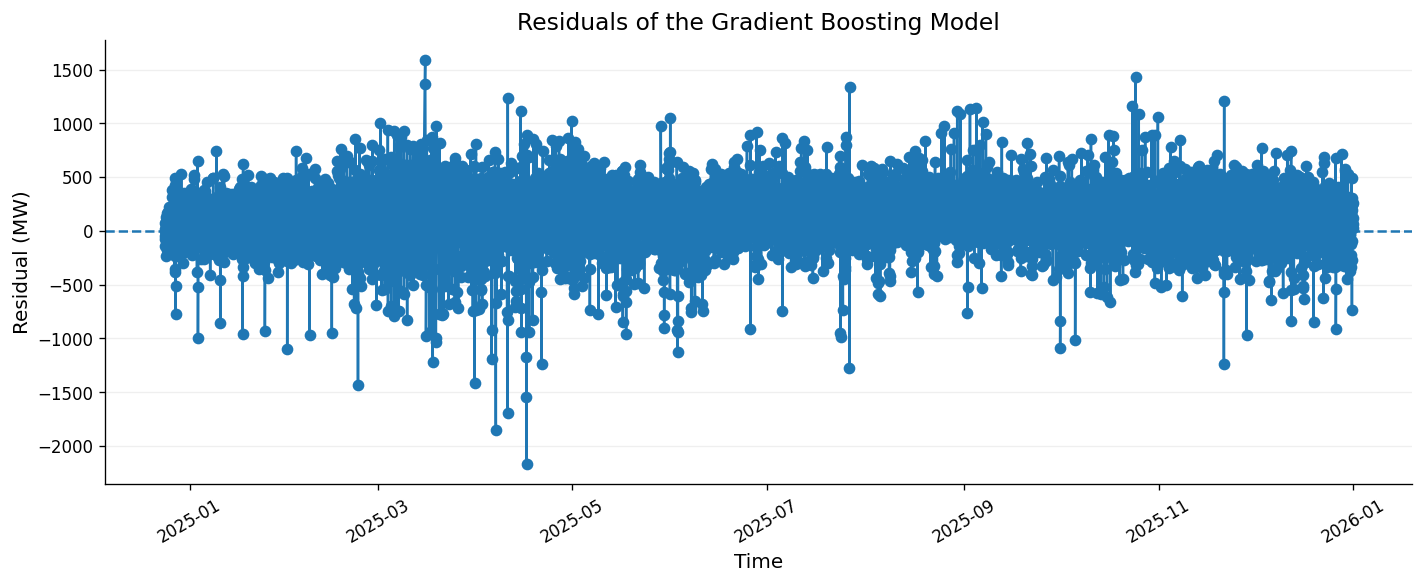

In [55]:
# ============================================================
# FIGURE 10 — GRADIENT BOOSTING RESIDUAL TIME SERIES
# ============================================================

# ------------------------------------------------------------
# 1. Get actual and predicted values
# ------------------------------------------------------------
actual_gb = np.asarray(y_te).ravel()
predicted_gb = np.asarray(pred_gb).ravel()

# ------------------------------------------------------------
# 2. Calculate residuals
# Residual = Actual - Predicted
# ------------------------------------------------------------
residual = actual_gb - predicted_gb

# ------------------------------------------------------------
# 3. Get timestamps corresponding to the ML test set
# ------------------------------------------------------------
# IMPORTANT:
# Use the same number of timestamps as the predictions.
#
# If your ML test set is stored in X_test and contains datetime,
# use that column instead. Otherwise, use the last N timestamps
# from the original dataframe.
# ------------------------------------------------------------

# Number of predictions
n_test = len(predicted_gb)

# Get the final n_test timestamps
test_times_gb = (
    pd.to_datetime(plot_df["datetime"])
    .iloc[-n_test:]
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Safety check
# ------------------------------------------------------------
print("Actual:", len(actual_gb))
print("Prediction:", len(predicted_gb))
print("Residual:", len(residual))
print("Time:", len(test_times_gb))

assert len(residual) == len(test_times_gb), \
    "Residuals and timestamps have different lengths!"

# ------------------------------------------------------------
# 5. Create residual plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    test_times_gb,
    residual,
    marker="o",
    linewidth=1.5
)

# Zero-error reference line
ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_title(
    "Residuals of the Gradient Boosting Model"
)

ax.set_xlabel("Time")
ax.set_ylabel("Residual (MW)")

ax.grid(
    axis="y",
    alpha=0.2
)

plt.xticks(rotation=30)

plt.tight_layout()

# ------------------------------------------------------------
# 6. Save high-resolution figure
# ------------------------------------------------------------
plt.savefig(
    "paper_figures/Fig10_residuals.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

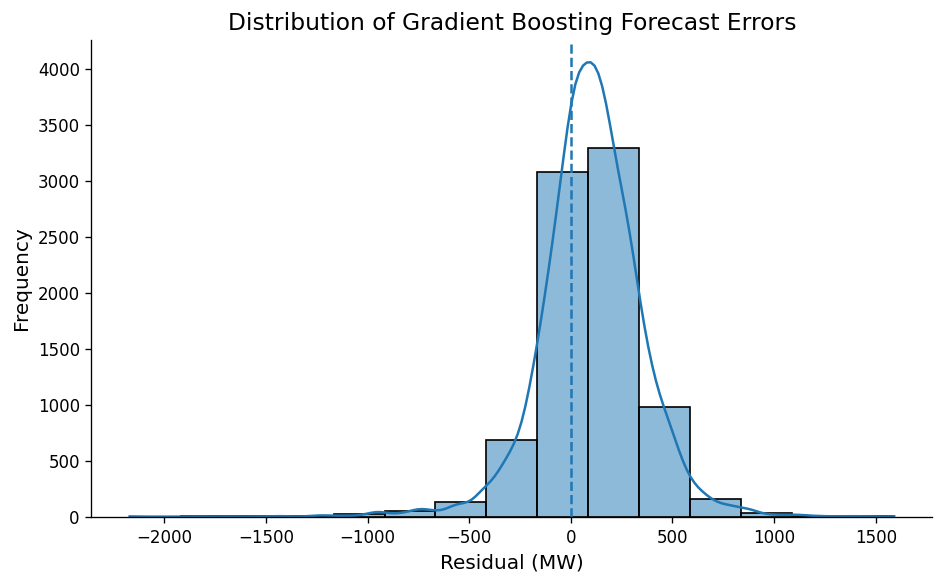

In [56]:
# ============================================================
# FIGURE 11 — RESIDUAL DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    residual,
    kde=True,
    bins=15,
    ax=ax
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_title("Distribution of Gradient Boosting Forecast Errors")
ax.set_xlabel("Residual (MW)")
ax.set_ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "paper_figures/Fig11_residual_distribution.png",
    bbox_inches="tight"
)

plt.show()

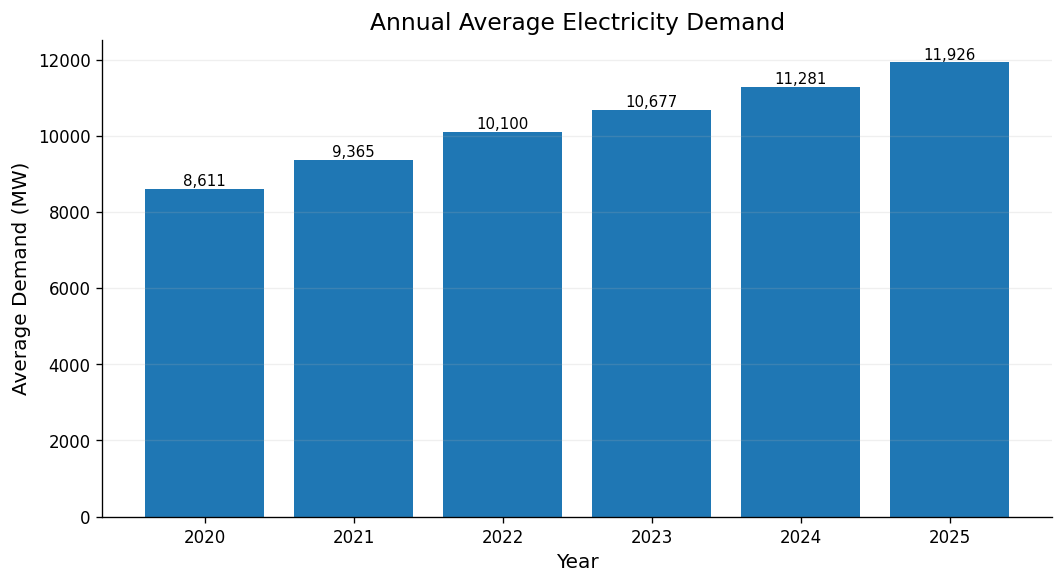

In [57]:
# ============================================================
# OPTIONAL FIGURE — YEARLY AVERAGE DEMAND
# ============================================================

yearly_demand = (
    plot_df
    .groupby(plot_df["datetime"].dt.year)["demand_mw"]
    .mean()
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    yearly_demand.index.astype(str),
    yearly_demand.values
)

ax.set_title("Annual Average Electricity Demand")
ax.set_xlabel("Year")
ax.set_ylabel("Average Demand (MW)")

for bar, value in zip(bars, yearly_demand.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "paper_figures/yearly_average_demand.png",
    bbox_inches="tight"
)

plt.show()

In [58]:
import os
import pickle
import joblib
import torch

MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save sklearn model
joblib.dump(m_gb, os.path.join(MODEL_DIR, "M_GBoosting.pkl"))

# Save XGBoost model
m_xgb_2.save_model(os.path.join(MODEL_DIR, "M_XGBoost.json"))
# Optional backup:
joblib.dump(m_xgb_2, os.path.join(MODEL_DIR, "M_XGBoost.pkl"))

# Save ANN model weights
torch.save(model.state_dict(), os.path.join(MODEL_DIR, "M_ANN.pth"))

# Save scaler used by ML models
joblib.dump(X_scaler, os.path.join(MODEL_DIR, "M_X_scaler.pkl"))

# Save StatsForecast object (SARIMA)
with open(os.path.join(MODEL_DIR, "M_SF.pkl"), "wb") as f:
    pickle.dump(sf, f)

print(f"All models saved in: {os.path.abspath(MODEL_DIR)}")
print("Saved files:")
for name in sorted(os.listdir(MODEL_DIR)):
    print(" -", name)

All models saved in: d:\Users\Md Mahfuzur Rahman\Desktop\Research\Final model\saved_models
Saved files:
 - M_ANN.pth
 - M_GBoosting.pkl
 - M_SF.pkl
 - M_XGBoost.json
 - M_XGBoost.pkl
 - M_X_scaler.pkl
 - feature_name.json
 - hourly_mean_demand.json
 - model_metadata.json


In [59]:
import json
import os

MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

feature_payload = {
    "features": FEATURES
}

with open(os.path.join(MODEL_DIR, "feature_name.json"), "w", encoding="utf-8") as f:
    json.dump(feature_payload, f, indent=2)

print(f"Saved feature list to: {os.path.abspath(os.path.join(MODEL_DIR, 'feature_name.json'))}")

Saved feature list to: d:\Users\Md Mahfuzur Rahman\Desktop\Research\Final model\saved_models\feature_name.json


In [60]:
# Save Gradient Boosting model metadata
metadata = {
    "model_name": "Gradient Boosting",
    "model_file": "M_GBoosting.pkl",
    "model_type": type(m_gb).__name__,
    "target": TARGET,
    "features": FEATURES,
    "scaler_file": "M_X_scaler.pkl",
    "training": {
        "n_samples": int(len(X_train)),
        "n_features": int(len(FEATURES)),
        "test_size": 0.20,
        "shuffle": False
    },
    "hyperparameters": {
        key: value.item() if isinstance(value, np.generic) else value
        for key, value in m_gb.get_params().items()
    },
    "performance": next(
        (row for row in results if row["Model"] == "Gradient Boosting"),
        None
    )
}

metadata_path = os.path.join(MODEL_DIR, "model_metadata.json")

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"Metadata saved to: {os.path.abspath(metadata_path)}")

Metadata saved to: d:\Users\Md Mahfuzur Rahman\Desktop\Research\Final model\saved_models\model_metadata.json
